In [37]:
%load_ext autoreload
%autoreload 2
import jax
import pgx
from pgx.experimental import auto_reset, act_randomly
from twentyfortyeight import *
import jax.numpy as jnp
from matplotlib import pyplot as plt
import numpy as np

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [38]:
env = pgx.make("minatar-space_invaders")
batch_size = 8192

init = jax.jit(jax.vmap(env.init))  # vectorize and JIT-compile
step = jax.jit(jax.vmap(auto_reset(env.step, env.init)))

key = jax.random.key(42)
key, subkey = jax.random.split(key)
keys = jax.random.split(subkey, batch_size)

In [39]:
state = init(keys)  # vectorized states
key, subkey = jax.random.split(key)
# policy_network = MLP(496, 4, subkey)
key, subkey = jax.random.split(key)
# value_network = MLP(496, 1, subkey)
obs_wrapper = ToInt(FlattenObservation())
ppo_network = model = PPONetwork(600, 4, key)
key, subkey = jax.random.split(key)
optim = optimizer = optax.chain(optax.clip_by_global_norm(
    0.5), optax.adam(1e-4, eps=1e-5))
grad_step = eqx.filter_jit(make_grad_step(ppo_network, ppo_loss, optim, subkey, 16))
# opt_state = optim.init(eqx.filter(model, eqx.is_array))
timesteps = 64

In [ ]:
losses = []
policy_losses = []
rewards = []
alternate_rewards = []
for i in range(10000):
    state, final_obs, traj = collect_trajectory(ppo_network, step, state, state.observation, key, timesteps, obs_wrapper=obs_wrapper)
    key, subkey = jax.random.split(key)
    (loss, metrics), ppo_network = grad_step(ppo_network, traj, final_obs, 0.99, 0.95, 0.2, 1, 0.01)
    losses.append(np.array(loss))
    policy_losses.append(np.array(metrics['policy_loss']))
    rewards.append(np.array(jnp.mean(traj.rewards)))
    alternate_rewards.append(np.array(jnp.sum(traj.rewards) / jnp.sum(traj.dones)))
    
# 32.7 minutes

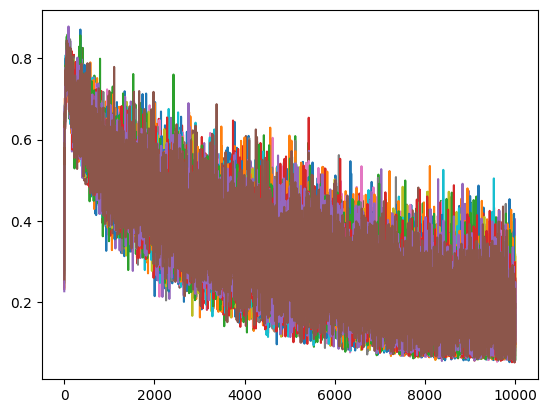

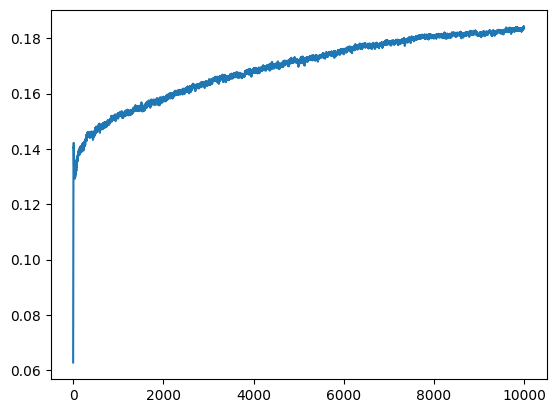

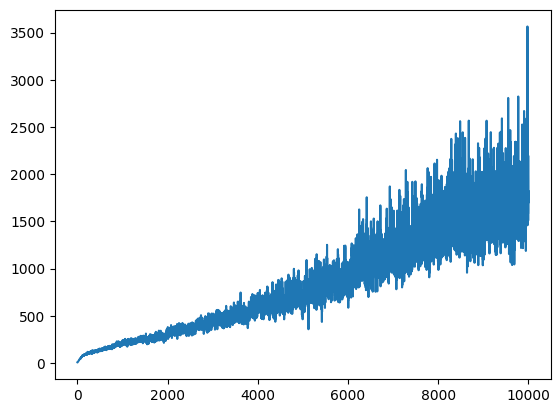

{'entropy_loss': Array([-0.15845414, -0.15813762, -0.15982226, -0.1570363 , -0.16018835,
       -0.15623839, -0.15522364, -0.15883316, -0.1534245 , -0.15618622,
       -0.15584475, -0.15777948, -0.15862095, -0.15763175, -0.15765801,
       -0.15826657], dtype=float32), 'policy_loss': Array([4.1206367e-06, 2.2872190e-03, 4.1223830e-03, 2.9577471e-03,
       2.5055311e-03, 2.7521420e-03, 3.5670670e-03, 3.0160956e-03,
       1.0041585e-03, 2.8796159e-03, 2.2456353e-03, 2.0042090e-03,
       1.7060509e-03, 2.3974630e-03, 1.2002934e-03, 2.4890522e-03],      dtype=float32), 'value_loss': Array([0.1037991 , 0.12933932, 0.05606054, 0.25066513, 0.17330578,
       0.23685472, 0.14092404, 0.07957494, 0.17715526, 0.21559651,
       0.18470621, 0.29809743, 0.05956746, 0.09647629, 0.24844241,
       0.18540944], dtype=float32)}


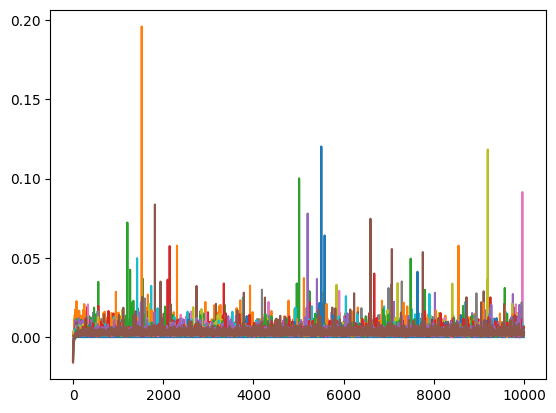

In [41]:
plt.plot(losses)
plt.show()
plt.plot(rewards)
plt.show()
plt.plot(alternate_rewards)
plt.show()
plt.plot(policy_losses)
print(metrics)

In [42]:
jnp.sum(traj.rewards) / jnp.sum(traj.dones)

Array(1820.717, dtype=float32)

In [47]:
jax.tree_util.tree_map(jnp.mean, (loss, metrics))

(Array(0.165495, dtype=float32),
 {'entropy_loss': Array(-0.15745914, dtype=float32),
  'policy_loss': Array(0.00232117, dtype=float32),
  'value_loss': Array(0.1647484, dtype=float32)})